# AI Phishing URL Detector

## Dataset Exploration

This notebook performs the initial exploration of the PhiUSIIL Phishing URL Dataset.

### Objectives

- Load and inspect the dataset.
- Understand the dataset structure.
- Examine feature types.
- Check for missing values and duplicates.
- Analyze the target distribution.
- Explore URL and domain characteristics.
- Identify security-relevant features.
- Establish observations that will guide feature engineering and model development.

The target variable is `label`:

- `1` = Phishing
- `0` = Legitimate

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load the Dataset

The dataset is stored in the project's `data/raw` directory.

We will load the original CSV without modifying it so that the raw dataset remains unchanged.

In [2]:
DATA_PATH = Path(
    "../data/raw/phiusiil/PhiUSIIL_Phishing_URL_Dataset.csv"
)

df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Dataset loaded successfully.
Rows: 235,795
Columns: 56


## 2. Preview the Dataset

The first few records help us understand the structure and the type of information available for each URL.

In [3]:
df.head()

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS,LineOfCode,LargestLineLength,HasTitle,Title,DomainTitleMatchScore,URLTitleMatchScore,HasFavicon,Robots,IsResponsive,NoOfURLRedirect,NoOfSelfRedirect,HasDescription,NoOfPopup,NoOfiFrame,HasExternalFormSubmit,HasSocialNet,HasSubmitButton,HasHiddenFields,HasPasswordField,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,3,1,0,0,0.0,18,0.581,0,0.0,0,0,0,1,0.032,1,558,9381,1,à¸‚à¹ˆà¸²à¸§à¸ªà¸” à¸‚à¹ˆà¸²à¸§à¸§à¸±à¸™à¸™à¸µà¹‰ à¸‚à¹ˆà¸²à¸§à¸à¸µà¸¬à¸² à¸‚à¹ˆà¸²à¸§à¸šà¸±à¸™...,0.000000,0.000000,0,1,1,0,0,0,0,1,0,0,1,1,0,1,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,2,1,0,0,0.0,9,0.391,0,0.0,0,0,0,2,0.087,1,618,9381,1,johannes gutenberg-universitÃ¤t mainz,55.555556,55.555556,1,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,2,2,0,0,0.0,15,0.517,0,0.0,0,0,0,2,0.069,1,467,682,1,voice fm southampton,46.666667,46.666667,0,1,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,3,1,0,0,0.0,13,0.500,0,0.0,0,0,0,1,0.038,1,6356,26824,1,home page: seminars in fetal and neonatal medicine,0.000000,0.000000,0,1,1,0,0,0,1,12,0,1,1,1,0,0,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,3,1,0,0,0.0,20,0.606,0,0.0,0,0,0,1,0.030,1,6089,28404,1,fundaciÃ³n rewilding argentina,100.000000,100.000000,0,1,1,1,1,1,0,2,0,1,1,1,0,1,1,0,1,244,15,34,72,1,85,1


In [4]:
df.tail()

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS,LineOfCode,LargestLineLength,HasTitle,Title,DomainTitleMatchScore,URLTitleMatchScore,HasFavicon,Robots,IsResponsive,NoOfURLRedirect,NoOfSelfRedirect,HasDescription,NoOfPopup,NoOfiFrame,HasExternalFormSubmit,HasSocialNet,HasSubmitButton,HasHiddenFields,HasPasswordField,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
235790,660997.txt,https://www.skincareliving.com,29,www.skincareliving.com,22,0,com,100.000000,1.000000,0.522907,0.058739,3,1,0,0,0.0,16,0.552,0,0.000,0,0,0,1,0.034,1,2007,9381,1,skincareliving,100.0,100.0,1,1,1,0,0,1,0,0,0,1,1,1,0,0,1,0,1,51,7,21,187,2,191,1
235791,77185.txt,https://www.winchester.gov.uk,28,www.winchester.gov.uk,21,0,uk,100.000000,0.785714,0.028555,0.053834,2,2,0,0,0.0,14,0.500,0,0.000,0,0,0,2,0.071,1,1081,348,1,winchestergov,0.0,0.0,1,0,1,0,0,1,0,0,0,1,1,1,0,0,1,0,0,50,1,7,88,0,31,1
235792,622132.txt,https://www.nononsensedesign.be,30,www.nononsensedesign.be,23,0,be,100.000000,1.000000,0.003319,0.063093,2,1,0,0,0.0,17,0.567,0,0.000,0,0,0,1,0.033,1,709,13277,1,nononsensedesign,100.0,100.0,1,1,1,0,0,1,0,0,0,1,1,0,0,0,0,0,1,27,10,30,58,2,67,1
235793,7503962.txt,https://patient-cell-40f5.updatedlogmylogin.workers.dev/,55,patient-cell-40f5.updatedlogmylogin.workers.dev,47,0,dev,28.157537,0.465116,0.000961,0.050211,3,2,0,0,0.0,39,0.709,3,0.055,0,0,0,5,0.091,1,125,1807,1,patient-cell-40f5updatedlogmyloginworkers,0.0,0.0,0,0,1,0,0,0,0,2,0,0,1,1,1,0,0,0,0,0,0,3,0,0,0,0
235794,384822.txt,https://www.alternativefinland.com,33,www.alternativefinland.com,26,0,com,100.000000,1.000000,0.522907,0.060596,3,1,0,0,0.0,20,0.606,0,0.000,0,0,0,1,0.030,1,1038,3346,1,alternativefinland,100.0,100.0,0,1,1,0,0,1,0,0,0,1,1,0,0,0,0,0,1,21,6,18,256,0,261,1


## 3. Dataset Structure

The dataset contains raw URL information, domain characteristics, URL-level statistical features, webpage-related security indicators, and the target label.

In [5]:
print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i:02d}. {column}")

Dataset shape:
(235795, 56)

Column names:
01. FILENAME
02. URL
03. URLLength
04. Domain
05. DomainLength
06. IsDomainIP
07. TLD
08. URLSimilarityIndex
09. CharContinuationRate
10. TLDLegitimateProb
11. URLCharProb
12. TLDLength
13. NoOfSubDomain
14. HasObfuscation
15. NoOfObfuscatedChar
16. ObfuscationRatio
17. NoOfLettersInURL
18. LetterRatioInURL
19. NoOfDegitsInURL
20. DegitRatioInURL
21. NoOfEqualsInURL
22. NoOfQMarkInURL
23. NoOfAmpersandInURL
24. NoOfOtherSpecialCharsInURL
25. SpacialCharRatioInURL
26. IsHTTPS
27. LineOfCode
28. LargestLineLength
29. HasTitle
30. Title
31. DomainTitleMatchScore
32. URLTitleMatchScore
33. HasFavicon
34. Robots
35. IsResponsive
36. NoOfURLRedirect
37. NoOfSelfRedirect
38. HasDescription
39. NoOfPopup
40. NoOfiFrame
41. HasExternalFormSubmit
42. HasSocialNet
43. HasSubmitButton
44. HasHiddenFields
45. HasPasswordField
46. Bank
47. Pay
48. Crypto
49. HasCopyrightInfo
50. NoOfImage
51. NoOfCSS
52. NoOfJS
53. NoOfSelfRef
54. NoOfEmptyRef
55. NoOfExter

## 4. Data Types

Understanding the data types is important before feature engineering.

The dataset contains:

- Numerical features
- Binary security indicators
- Categorical features such as TLD
- Text features such as URL and Title

In [6]:
df.dtypes

FILENAME                          str
URL                               str
URLLength                       int64
Domain                            str
DomainLength                    int64
IsDomainIP                      int64
TLD                               str
URLSimilarityIndex            float64
CharContinuationRate          float64
TLDLegitimateProb             float64
URLCharProb                   float64
TLDLength                       int64
NoOfSubDomain                   int64
HasObfuscation                  int64
NoOfObfuscatedChar              int64
ObfuscationRatio              float64
NoOfLettersInURL                int64
LetterRatioInURL              float64
NoOfDegitsInURL                 int64
DegitRatioInURL               float64
NoOfEqualsInURL                 int64
NoOfQMarkInURL                  int64
NoOfAmpersandInURL              int64
NoOfOtherSpecialCharsInURL      int64
SpacialCharRatioInURL         float64
IsHTTPS                         int64
LineOfCode  

In [7]:
print("Data type distribution:")
print(df.dtypes.value_counts())

Data type distribution:
int64      41
float64    10
str         5
Name: count, dtype: int64


## 5. Missing Values

Missing values can affect model training and feature engineering.

We will check every column for missing values.

In [8]:
missing_values = df.isnull().sum()

missing_summary = (
    missing_values[missing_values > 0]
    .sort_values(ascending=False)
)

if missing_summary.empty:
    print("No missing values were found in the dataset.")
else:
    display(missing_summary)

No missing values were found in the dataset.


## 6. Duplicate Records

Duplicate URLs or records can introduce bias during model training.

We will check for:

1. Completely duplicated rows.
2. Duplicated URLs.

In [9]:
duplicate_rows = df.duplicated().sum()
duplicate_urls = df["URL"].duplicated().sum()

print(f"Duplicate rows: {duplicate_rows:,}")
print(f"Duplicate URLs: {duplicate_urls:,}")

Duplicate rows: 0
Duplicate URLs: 425


## 7. Target Variable

The `label` column is the target variable used for supervised learning.

For this project:

- `0` represents a legitimate URL.
- `1` represents a phishing URL.

Understanding the class distribution is important because an imbalanced dataset can affect model evaluation.

In [10]:
label_counts = df["label"].value_counts().sort_index()

label_percentages = (
    df["label"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

target_summary = pd.DataFrame({
    "Count": label_counts,
    "Percentage": label_percentages.round(2)
})

target_summary.index = [
    "Legitimate (0)",
    "Phishing (1)"
]

target_summary

,Count,Percentage
Legitimate (0),100945,42.81
Phishing (1),134850,57.19


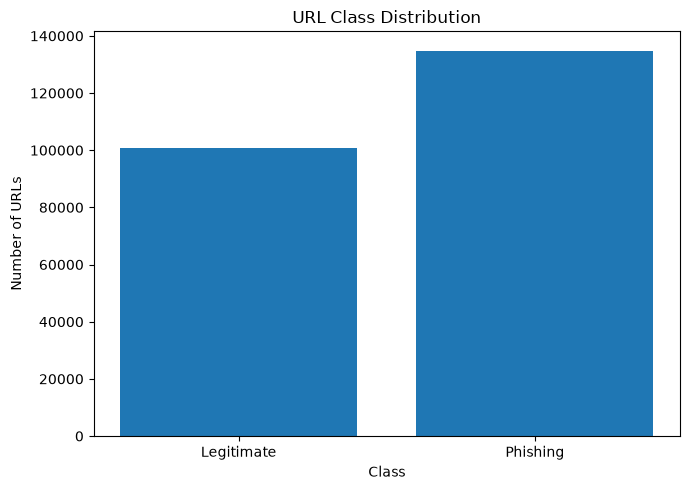

In [11]:
plt.figure(figsize=(7, 5))

plt.bar(
    ["Legitimate", "Phishing"],
    label_counts.values
)

plt.title("URL Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of URLs")

plt.tight_layout()
plt.show()

## 8. URL Characteristics

The URL itself contains potentially useful security signals.

Examples include:

- URL length
- Domain length
- Number of subdomains
- Number of digits
- Number of special characters
- HTTPS usage
- Whether the domain is represented by an IP address
- Obfuscation indicators

These characteristics will become especially important during feature engineering.

In [12]:
url_features = [
    "URLLength",
    "DomainLength",
    "IsDomainIP",
    "TLDLength",
    "NoOfSubDomain",
    "NoOfLettersInURL",
    "NoOfDegitsInURL",
    "NoOfEqualsInURL",
    "NoOfQMarkInURL",
    "NoOfAmpersandInURL",
    "NoOfOtherSpecialCharsInURL",
    "IsHTTPS",
    "HasObfuscation",
    "NoOfObfuscatedChar",
    "ObfuscationRatio"
]

df[url_features].describe().T

,count,mean,std,min,25%,50%,75%,max
URLLength,235795.0,34.573095,41.314153,13.0,23.0,27.0,34.0,6097.000
DomainLength,235795.0,21.470396,9.150793,4.0,16.0,20.0,24.0,110.000
IsDomainIP,235795.0,0.002706,0.051946,0.0,0.0,0.0,0.0,1.000
TLDLength,235795.0,2.764456,0.599739,2.0,2.0,3.0,3.0,13.000
NoOfSubDomain,235795.0,1.164758,0.600969,0.0,1.0,1.0,1.0,10.000
NoOfLettersInURL,235795.0,19.428919,29.090330,0.0,10.0,14.0,20.0,5191.000
NoOfDegitsInURL,235795.0,1.881011,11.886695,0.0,0.0,0.0,0.0,2011.000
NoOfEqualsInURL,235795.0,0.062241,0.934704,0.0,0.0,0.0,0.0,176.000
NoOfQMarkInURL,235795.0,0.029403,0.193505,0.0,0.0,0.0,0.0,4.000
NoOfAmpersandInURL,235795.0,0.025056,0.836448,0.0,0.0,0.0,0.0,149.000


## 9. Security-Relevant Features

The dataset provides several features that may represent suspicious URL or webpage behavior.

Examples include:

- Domain represented by an IP address
- URL obfuscation
- Excessive subdomains
- URL redirects
- Self redirects
- External form submission
- Password fields
- Hidden fields
- Popups
- Iframes
- External references
- Suspicious financial keywords

These features provide useful signals for phishing detection.

In [13]:
security_features = [
    "IsDomainIP",
    "HasObfuscation",
    "IsHTTPS",
    "NoOfURLRedirect",
    "NoOfSelfRedirect",
    "HasExternalFormSubmit",
    "HasPasswordField",
    "HasHiddenFields",
    "NoOfPopup",
    "NoOfiFrame",
    "Bank",
    "Pay",
    "Crypto",
    "NoOfExternalRef"
]

df[security_features].describe().T

,count,mean,std,min,25%,50%,75%,max
IsDomainIP,235795.0,0.002706,0.051946,0.0,0.0,0.0,0.0,1.0
HasObfuscation,235795.0,0.002057,0.045306,0.0,0.0,0.0,0.0,1.0
IsHTTPS,235795.0,0.782625,0.412461,0.0,1.0,1.0,1.0,1.0
NoOfURLRedirect,235795.0,0.133438,0.340048,0.0,0.0,0.0,0.0,1.0
NoOfSelfRedirect,235795.0,0.040107,0.196210,0.0,0.0,0.0,0.0,1.0
HasExternalFormSubmit,235795.0,0.043987,0.205067,0.0,0.0,0.0,0.0,1.0
HasPasswordField,235795.0,0.102263,0.302994,0.0,0.0,0.0,0.0,1.0
HasHiddenFields,235795.0,0.377799,0.484838,0.0,0.0,0.0,1.0,1.0
NoOfPopup,235795.0,0.221765,3.870540,0.0,0.0,0.0,0.0,602.0
NoOfiFrame,235795.0,1.588638,5.762561,0.0,0.0,0.0,1.0,1602.0


## 10. HTTPS Analysis

HTTPS is an important security feature, but HTTPS alone does not prove that a website is legitimate.

Phishing websites can also use HTTPS.

Therefore, `IsHTTPS` should be treated as one feature among many rather than as a definitive phishing indicator.

In [14]:
https_analysis = pd.crosstab(
    df["IsHTTPS"],
    df["label"],
    normalize="index"
) * 100

https_analysis.columns = [
    "Legitimate (%)",
    "Phishing (%)"
]

https_analysis

,Legitimate (%),Phishing (%)
IsHTTPS,,
0,100.000000,0.000000
1,26.926016,73.073984


## 11. IP-Based Domain Analysis

A URL that directly uses an IP address instead of a conventional domain name can be a suspicious signal.

However, legitimate applications can also use IP addresses.

This makes `IsDomainIP` a useful model feature rather than a standalone detection rule.

In [15]:
ip_domain_analysis = pd.crosstab(
    df["IsDomainIP"],
    df["label"],
    normalize="index"
) * 100

ip_domain_analysis.columns = [
    "Legitimate (%)",
    "Phishing (%)"
]

ip_domain_analysis

,Legitimate (%),Phishing (%)
IsDomainIP,,
0,42.655332,57.344668
1,100.000000,0.000000


## 12. URL Length by Class

Long URLs can sometimes indicate tracking parameters, redirects, obfuscation, or attempts to hide the true destination.

We will compare URL length between legitimate and phishing URLs.

In [16]:
df.groupby("label")["URLLength"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100945.0,45.720293,61.145523,13.0,26.0,34.0,48.0,6097.0
1,134850.0,26.228610,4.815612,15.0,23.0,26.0,29.0,57.0


<Figure size 800x500 with 0 Axes>

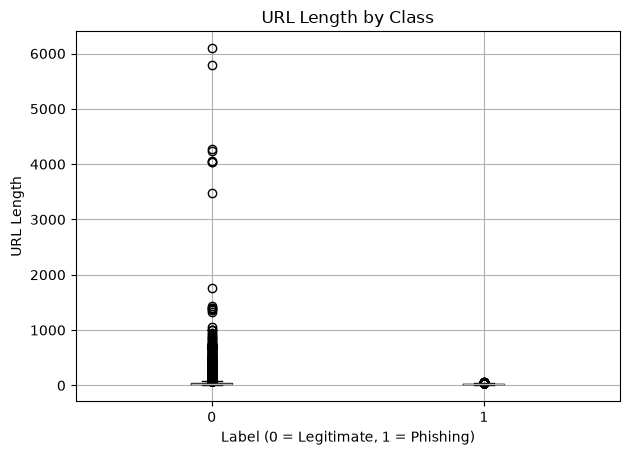

In [17]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="URLLength",
    by="label"
)

plt.title("URL Length by Class")
plt.suptitle("")
plt.xlabel("Label (0 = Legitimate, 1 = Phishing)")
plt.ylabel("URL Length")

plt.tight_layout()
plt.show()

## 13. Number of Subdomains

Excessive subdomain nesting can sometimes be used to make a malicious domain appear trustworthy.

For example:

`secure.login.account.example.com`

The number of subdomains is therefore worth examining as a potential phishing signal.

In [18]:
df.groupby("label")["NoOfSubDomain"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100945.0,1.168894,0.790880,0.0,1.0,1.0,1.0,10.0
1,134850.0,1.161661,0.404076,1.0,1.0,1.0,1.0,4.0


## 14. Obfuscation Analysis

URL obfuscation can make a destination difficult for users or automated systems to interpret.

The dataset provides:

- `HasObfuscation`
- `NoOfObfuscatedChar`
- `ObfuscationRatio`

These features will be examined further during feature engineering.

In [19]:
obfuscation_analysis = df.groupby("label")[
    [
        "HasObfuscation",
        "NoOfObfuscatedChar",
        "ObfuscationRatio"
    ]
].mean()

obfuscation_analysis

,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio
label,,,
0,0.004805,0.058071,0.000323
1,0.000000,0.000000,0.000000


## 15. Top-Level Domains

The `TLD` feature identifies the top-level domain associated with each URL.

TLD information can provide useful statistical signals, although the TLD itself should not be treated as proof that a URL is malicious.

In [20]:
tld_counts = (
    df["TLD"]
    .value_counts()
    .head(20)
)

tld_counts

TLD
com     112554
org      18793
net       7097
app       6508
uk        6395
co        5422
io        4201
de        3996
ru        3875
au        2979
dev       2345
top       2329
jp        2219
it        1887
edu       1861
fr        1858
br        1846
nl        1727
ca        1614
info      1566
Name: count, dtype: int64

## 16. Initial Observations

Based on the exploration above, the dataset provides several categories of potentially useful information:

### URL-Level Features

- URL length
- Domain length
- Number of subdomains
- Character composition
- Special characters
- Digits
- Obfuscation

### Domain-Level Features

- TLD
- IP-based domain
- Domain characteristics
- Domain/title similarity

### Webpage-Level Features

- Redirects
- Iframes
- Forms
- Password fields
- Hidden fields
- Popups
- External references

### Security Indicators

- Banking-related indicators
- Payment-related indicators
- Cryptocurrency-related indicators
- HTTPS usage

These features provide a strong foundation for developing a phishing URL detection model.

# Conclusion

The initial exploration confirms that the PhiUSIIL dataset contains a large number of labeled URLs and a broad collection of URL, domain, webpage, and security-related features.

The dataset contains:

- 235,795 records
- 56 columns
- No detected missing values
- A binary phishing classification target
- Multiple URL-level security indicators

The next stage of the project will focus on **feature engineering**.

Instead of relying blindly on the existing dataset features, we will create additional security-oriented features directly from the URL.

Examples include:

- URL character counts
- Suspicious symbol detection
- Suspicious keyword detection
- Domain structure analysis
- Subdomain analysis
- IP address detection
- Encoding and obfuscation indicators
- URL entropy
- Scheme analysis

These engineered features will then be evaluated and incorporated into the machine-learning pipeline.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "../data/raw/phiusiil/PhiUSIIL_Phishing_URL_Dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (235795, 56)


In [4]:
print("Label distribution:")
print(df["label"].value_counts())

print("\nLabel percentages:")
print((df["label"].value_counts(normalize=True) * 100).round(2))

Label distribution:
label
1    134850
0    100945
Name: count, dtype: int64

Label percentages:
label
1    57.19
0    42.81
Name: proportion, dtype: float64


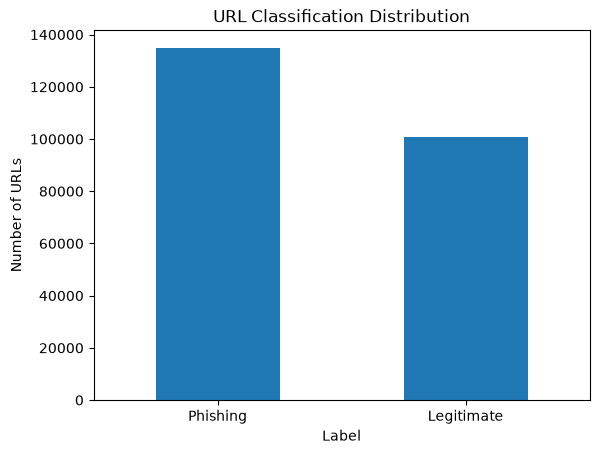

In [5]:
df["label"].value_counts().plot(
    kind="bar",
    title="URL Classification Distribution",
    xlabel="Label",
    ylabel="Number of URLs"
)

plt.xticks(
    ticks=[0, 1],
    labels=["Phishing", "Legitimate"],
    rotation=0
)

plt.show()

In [6]:
url_features = [
    "URLLength",
    "DomainLength",
    "NoOfSubDomain",
    "NoOfLettersInURL",
    "NoOfDegitsInURL",
    "NoOfEqualsInURL",
    "NoOfQMarkInURL",
    "NoOfAmpersandInURL",
    "NoOfOtherSpecialCharsInURL",
    "SpacialCharRatioInURL"
]

df[url_features].describe().T

,count,mean,std,min,25%,50%,75%,max
URLLength,235795.0,34.573095,41.314153,13.0,23.000,27.00,34.000,6097.000
DomainLength,235795.0,21.470396,9.150793,4.0,16.000,20.00,24.000,110.000
NoOfSubDomain,235795.0,1.164758,0.600969,0.0,1.000,1.00,1.000,10.000
NoOfLettersInURL,235795.0,19.428919,29.090330,0.0,10.000,14.00,20.000,5191.000
NoOfDegitsInURL,235795.0,1.881011,11.886695,0.0,0.000,0.00,0.000,2011.000
NoOfEqualsInURL,235795.0,0.062241,0.934704,0.0,0.000,0.00,0.000,176.000
NoOfQMarkInURL,235795.0,0.029403,0.193505,0.0,0.000,0.00,0.000,4.000
NoOfAmpersandInURL,235795.0,0.025056,0.836448,0.0,0.000,0.00,0.000,149.000
NoOfOtherSpecialCharsInURL,235795.0,2.340198,3.527603,0.0,1.000,1.00,3.000,499.000
SpacialCharRatioInURL,235795.0,0.063309,0.032393,0.0,0.038,0.05,0.083,0.397


In [7]:
df.groupby("label")[url_features].mean().round(2)

,URLLength,DomainLength,NoOfSubDomain,NoOfLettersInURL,NoOfDegitsInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL
label,,,,,,,,,,
0,45.72,24.47,1.17,28.11,4.33,0.15,0.07,0.06,3.80,0.08
1,26.23,19.23,1.16,12.93,0.05,0.00,0.00,0.00,1.24,0.05


In [8]:
security_features = [
    "IsDomainIP",
    "HasObfuscation",
    "IsHTTPS",
    "NoOfURLRedirect",
    "NoOfSelfRedirect",
    "HasExternalFormSubmit",
    "HasPasswordField",
    "HasHiddenFields"
]

df.groupby("label")[security_features].mean().round(3)

,IsDomainIP,HasObfuscation,IsHTTPS,NoOfURLRedirect,NoOfSelfRedirect,HasExternalFormSubmit,HasPasswordField,HasHiddenFields
label,,,,,,,,
0,0.006,0.005,0.492,0.152,0.057,0.004,0.054,0.093
1,0.000,0.000,1.000,0.120,0.027,0.074,0.138,0.591


In [9]:
suspicious_features = [
    "Bank",
    "Pay",
    "Crypto",
    "HasSubmitButton",
    "NoOfPopup",
    "NoOfiFrame"
]

df.groupby("label")[suspicious_features].mean().round(3)

,Bank,Pay,Crypto,HasSubmitButton,NoOfPopup,NoOfiFrame
label,,,,,,
0,0.054,0.060,0.006,0.085,0.01,0.085
1,0.182,0.369,0.037,0.661,0.38,2.715


In [10]:
numeric_columns = df.select_dtypes(include=["int64", "float64"])

correlations = (
    numeric_columns
    .corr()["label"]
    .drop("label")
    .sort_values(key=abs, ascending=False)
)

correlations.head(20)

URLSimilarityIndex       0.860358
HasSocialNet             0.784255
HasCopyrightInfo         0.743358
HasDescription           0.690232
IsHTTPS                  0.609132
DomainTitleMatchScore    0.584905
HasSubmitButton          0.578561
IsResponsive             0.548608
URLTitleMatchScore       0.539419
SpacialCharRatioInURL   -0.533537
HasHiddenFields          0.507731
HasFavicon               0.493711
URLCharProb              0.469749
CharContinuationRate     0.467735
HasTitle                 0.459725
DegitRatioInURL         -0.432032
Robots                   0.392620
NoOfJS                   0.373500
LetterRatioInURL        -0.367794
Pay                      0.359747
Name: label, dtype: float64

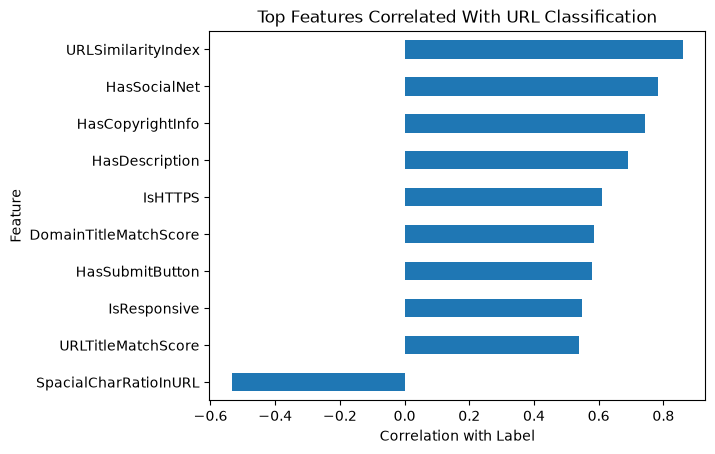

In [11]:
top_features = correlations.head(10)

top_features.sort_values().plot(
    kind="barh",
    title="Top Features Correlated With URL Classification",
    xlabel="Correlation with Label",
    ylabel="Feature"
)

plt.show()

In [12]:
duplicate_urls = df["URL"].duplicated().sum()

print(f"Duplicate URLs: {duplicate_urls}")
print(
    f"Duplicate percentage: "
    f"{duplicate_urls / len(df) * 100:.2f}%"
)

Duplicate URLs: 425
Duplicate percentage: 0.18%


In [13]:
print("Legitimate URL examples:")
display(
    df[df["label"] == 1][["URL", "Domain", "TLD"]].head(10)
)

print("\nPhishing URL examples:")
display(
    df[df["label"] == 0][["URL", "Domain", "TLD"]].head(10)
)

Legitimate URL examples:


,URL,Domain,TLD
0,https://www.southbankmosaics.com,www.southbankmosaics.com,com
1,https://www.uni-mainz.de,www.uni-mainz.de,de
2,https://www.voicefmradio.co.uk,www.voicefmradio.co.uk,uk
3,https://www.sfnmjournal.com,www.sfnmjournal.com,com
4,https://www.rewildingargentina.org,www.rewildingargentina.org,org
5,https://www.globalreporting.org,www.globalreporting.org,org
6,https://www.saffronart.com,www.saffronart.com,com
7,https://www.nerdscandy.com,www.nerdscandy.com,com
8,https://www.hyderabadonline.in,www.hyderabadonline.in,in
9,https://www.aap.org,www.aap.org,org



Phishing URL examples:


,URL,Domain,TLD
11,http://www.teramill.com,www.teramill.com,com
20,http://www.f0519141.xsph.ru,www.f0519141.xsph.ru,ru
21,http://www.shprakserf.gq,www.shprakserf.gq,gq
27,https://service-mitld.firebaseapp.com/,service-mitld.firebaseapp.com,com
28,http://www.kuradox92.lima-city.de,www.kuradox92.lima-city.de,de
29,https://liuy-9a930.web.app/,liuy-9a930.web.app,app
31,https://ipfs.io/ipfs/qmrvvyr84esa2assw9vvwupqj...,ipfs.io,io
32,http://att-103731-107123.weeblysite.com/,att-103731-107123.weeblysite.com,com
34,https://hidok4f8zl.firebaseapp.com/,hidok4f8zl.firebaseapp.com,com
37,http://www.ooguy.com,www.ooguy.com,com


In [14]:
print(df.groupby("label")["URL"].count())
print(df.groupby("label")["URL"].first())

label
0    100945
1    134850
Name: URL, dtype: int64
label
0             http://www.teramill.com
1    https://www.southbankmosaics.com
Name: URL, dtype: str


# Feature Engineering

The raw dataset contains URL, domain, structural, content, and security-related features.

Feature engineering will be used to:

- Select relevant predictive features.
- Remove identifiers and text fields that are not required for the initial model.
- Create additional URL security indicators.
- Prepare a clean feature matrix for machine-learning models.

In [15]:
feature_columns = [
    "URLLength",
    "DomainLength",
    "IsDomainIP",
    "URLSimilarityIndex",
    "CharContinuationRate",
    "TLDLegitimateProb",
    "URLCharProb",
    "TLDLength",
    "NoOfSubDomain",
    "HasObfuscation",
    "NoOfObfuscatedChar",
    "ObfuscationRatio",
    "NoOfLettersInURL",
    "LetterRatioInURL",
    "NoOfDegitsInURL",
    "DegitRatioInURL",
    "NoOfEqualsInURL",
    "NoOfQMarkInURL",
    "NoOfAmpersandInURL",
    "NoOfOtherSpecialCharsInURL",
    "SpacialCharRatioInURL",
    "IsHTTPS",
    "NoOfURLRedirect",
    "NoOfSelfRedirect",
    "HasExternalFormSubmit",
    "HasSocialNet",
    "HasSubmitButton",
    "HasHiddenFields",
    "HasPasswordField",
    "Bank",
    "Pay",
    "Crypto",
    "HasCopyrightInfo",
    "HasFavicon",
    "Robots",
    "IsResponsive",
    "HasTitle",
    "DomainTitleMatchScore",
    "URLTitleMatchScore",
    "HasDescription",
    "NoOfPopup",
    "NoOfiFrame",
    "NoOfImage",
    "NoOfCSS",
    "NoOfJS",
    "NoOfSelfRef",
    "NoOfEmptyRef",
    "NoOfExternalRef"
]

X = df[feature_columns].copy()
y = df["label"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (235795, 48)
Target shape: (235795,)


In [16]:
print("Number of features:", X.shape[1])
print("\nMissing values:", X.isnull().sum().sum())
print("\nTarget distribution:")
print(y.value_counts())

Number of features: 48

Missing values: 0

Target distribution:
label
1    134850
0    100945
Name: count, dtype: int64


In [17]:
X["SuspiciousCharacterDensity"] = (
    X["NoOfOtherSpecialCharsInURL"] /
    X["URLLength"].replace(0, 1)
)

X["DigitDensity"] = (
    X["NoOfDegitsInURL"] /
    X["URLLength"].replace(0, 1)
)

X["SubdomainDensity"] = (
    X["NoOfSubDomain"] /
    X["DomainLength"].replace(0, 1)
)

X["RedirectDensity"] = (
    X["NoOfURLRedirect"] /
    X["URLLength"].replace(0, 1)
)

X["ExternalReferenceRatio"] = (
    X["NoOfExternalRef"] /
    (X["NoOfSelfRef"] + X["NoOfExternalRef"]).replace(0, 1)
)

print("Feature matrix after engineering:", X.shape)

Feature matrix after engineering: (235795, 53)


In [18]:
X["SecurityRiskScore"] = (
    X["IsDomainIP"]
    + X["HasObfuscation"]
    + X["HasExternalFormSubmit"]
    + X["HasHiddenFields"]
    + X["HasPasswordField"]
    + (X["NoOfURLRedirect"] > 0).astype(int)
    + (X["NoOfSubDomain"] > 2).astype(int)
)

In [19]:
print(X["SecurityRiskScore"].describe())

count    235795.000000
mean          0.692161
std           0.812242
min           0.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           5.000000
Name: SecurityRiskScore, dtype: float64


In [20]:
engineered_features = [
    "SuspiciousCharacterDensity",
    "DigitDensity",
    "SubdomainDensity",
    "RedirectDensity",
    "ExternalReferenceRatio",
    "SecurityRiskScore"
]

comparison = df.assign(
    SuspiciousCharacterDensity=X["SuspiciousCharacterDensity"],
    DigitDensity=X["DigitDensity"],
    SubdomainDensity=X["SubdomainDensity"],
    RedirectDensity=X["RedirectDensity"],
    ExternalReferenceRatio=X["ExternalReferenceRatio"],
    SecurityRiskScore=X["SecurityRiskScore"]
).groupby("label")[engineered_features].mean()

comparison.round(4)

,SuspiciousCharacterDensity,DigitDensity,SubdomainDensity,RedirectDensity,ExternalReferenceRatio,SecurityRiskScore
label,,,,,,
0,0.0814,0.0640,0.0493,0.0044,0.3694,0.3668
1,0.0484,0.0021,0.0637,0.0047,0.4433,0.9357


In [21]:
engineered_correlations = (
    X[engineered_features]
    .join(y)
    .corr()["label"]
    .drop("label")
    .sort_values(key=abs, ascending=False)
)

engineered_correlations

SuspiciousCharacterDensity   -0.521377
DigitDensity                 -0.432056
SecurityRiskScore             0.346614
SubdomainDensity              0.249135
ExternalReferenceRatio        0.107218
RedirectDensity               0.012601
Name: label, dtype: float64

In [22]:
processed_df = X.copy()
processed_df["label"] = y

print("Processed dataset shape:", processed_df.shape)
print("\nColumns:")
print(processed_df.columns.tolist())

Processed dataset shape: (235795, 55)

Columns:
['URLLength', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'HasFavicon', 'Robots', 'IsResponsive', 'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'SuspiciousCharacterDensity', 'DigitDensity', 'SubdomainDensity', 'RedirectDensity', 'ExternalReferenceRatio', 'SecurityRi

In [23]:
import os

os.makedirs("../data/processed", exist_ok=True)

processed_path = "../data/processed/url_features.csv"

processed_df.to_csv(
    processed_path,
    index=False
)

print(f"Processed dataset saved to: {processed_path}")

Processed dataset saved to: ../data/processed/url_features.csv


In [24]:
processed_check = pd.read_csv(processed_path)

print("Reloaded shape:", processed_check.shape)
print("Missing values:", processed_check.isnull().sum().sum())
print("Target distribution:")
print(processed_check["label"].value_counts())

Reloaded shape: (235795, 55)
Missing values: 0
Target distribution:
label
1    134850
0    100945
Name: count, dtype: int64


In [25]:
print("Processed dataset shape:", processed_df.shape)
print(engineered_correlations)

Processed dataset shape: (235795, 55)
SuspiciousCharacterDensity   -0.521377
DigitDensity                 -0.432056
SecurityRiskScore             0.346614
SubdomainDensity              0.249135
ExternalReferenceRatio        0.107218
RedirectDensity               0.012601
Name: label, dtype: float64


# Train/Test Split

The processed dataset will be divided into training and testing subsets.

The training set will be used to learn patterns from the URL features.

The test set will remain unseen during training and will be used to evaluate how well the model generalizes to new URLs.

A stratified split is used to preserve the proportion of phishing and legitimate URLs in both subsets.

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X = processed_df.drop(columns=["label"])
y = processed_df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (235795, 54)
y shape: (235795,)


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTraining labels:")
print(y_train.value_counts())

print("\nTesting labels:")
print(y_test.value_counts())

Training features: (188636, 54)
Testing features: (47159, 54)

Training labels:
label
1    107880
0     80756
Name: count, dtype: int64

Testing labels:
label
1    26970
0    20189
Name: count, dtype: int64


In [29]:
print("Training distribution:")
print(
    y_train.value_counts(normalize=True)
    .sort_index()
    .round(4)
)

print("\nTesting distribution:")
print(
    y_test.value_counts(normalize=True)
    .sort_index()
    .round(4)
)

Training distribution:
label
0    0.4281
1    0.5719
Name: proportion, dtype: float64

Testing distribution:
label
0    0.4281
1    0.5719
Name: proportion, dtype: float64


# Baseline Machine Learning Model

A Random Forest classifier will be used as the initial machine-learning model.

Random Forest is suitable for this dataset because the feature matrix contains numerical URL and security characteristics, including binary indicators, counts, ratios, and engineered security features.

In [30]:
from sklearn.ensemble import RandomForestClassifier

In [31]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

In [32]:
print("Training Random Forest...")

model.fit(X_train, y_train)

print("Training complete.")

Training Random Forest...
Training complete.


In [33]:
y_pred = model.predict(X_test)

y_probability = model.predict_proba(X_test)[:, 1]

print("Predictions generated.")
print("Number of predictions:", len(y_pred))

Predictions generated.
Number of predictions: 47159


In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [35]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000


In [36]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Phishing", "Legitimate"]
    )
)

              precision    recall  f1-score   support

    Phishing       1.00      1.00      1.00     20189
  Legitimate       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



In [37]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[20189     0]
 [    0 26970]]


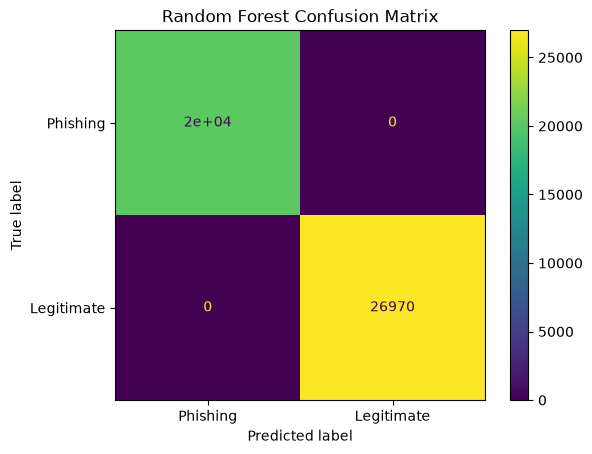

In [38]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Phishing", "Legitimate"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [39]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

In [40]:
print("Top 20 Most Important Features:")
print(feature_importance.head(20))

Top 20 Most Important Features:
URLSimilarityIndex            0.167202
NoOfExternalRef               0.151265
NoOfSelfRef                   0.116121
NoOfImage                     0.114534
NoOfJS                        0.092917
NoOfCSS                       0.071840
HasSocialNet                  0.048160
HasCopyrightInfo              0.036581
HasDescription                0.029910
NoOfOtherSpecialCharsInURL    0.026736
ExternalReferenceRatio        0.023858
IsHTTPS                       0.014755
NoOfiFrame                    0.009391
URLLength                     0.009207
DomainTitleMatchScore         0.008632
NoOfDegitsInURL               0.007203
HasSubmitButton               0.007094
DigitDensity                  0.007092
IsResponsive                  0.006964
URLTitleMatchScore            0.005567
dtype: float64


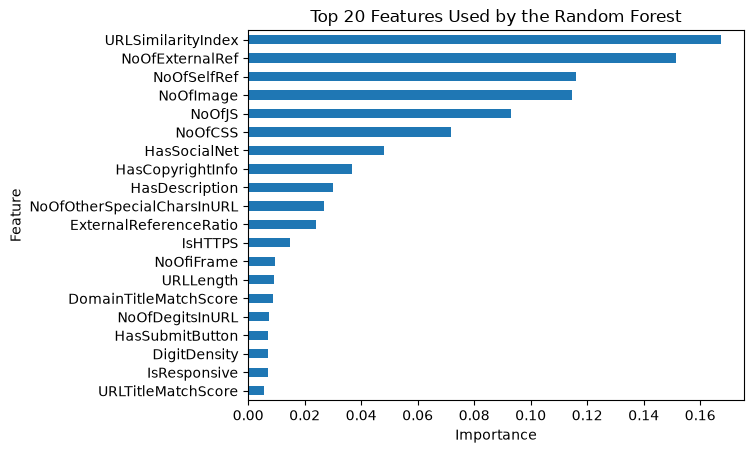

In [41]:
feature_importance.head(20).sort_values().plot(
    kind="barh",
    title="Top 20 Features Used by the Random Forest",
    xlabel="Importance",
    ylabel="Feature"
)

plt.show()

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Top 20 Most Important Features:")
print(feature_importance.head(20))

Top 20 Most Important Features:
URLSimilarityIndex            0.167202
NoOfExternalRef               0.151265
NoOfSelfRef                   0.116121
NoOfImage                     0.114534
NoOfJS                        0.092917
NoOfCSS                       0.071840
HasSocialNet                  0.048160
HasCopyrightInfo              0.036581
HasDescription                0.029910
NoOfOtherSpecialCharsInURL    0.026736
ExternalReferenceRatio        0.023858
IsHTTPS                       0.014755
NoOfiFrame                    0.009391
URLLength                     0.009207
DomainTitleMatchScore         0.008632
NoOfDegitsInURL               0.007203
HasSubmitButton               0.007094
DigitDensity                  0.007092
IsResponsive                  0.006964
URLTitleMatchScore            0.005567
dtype: float64


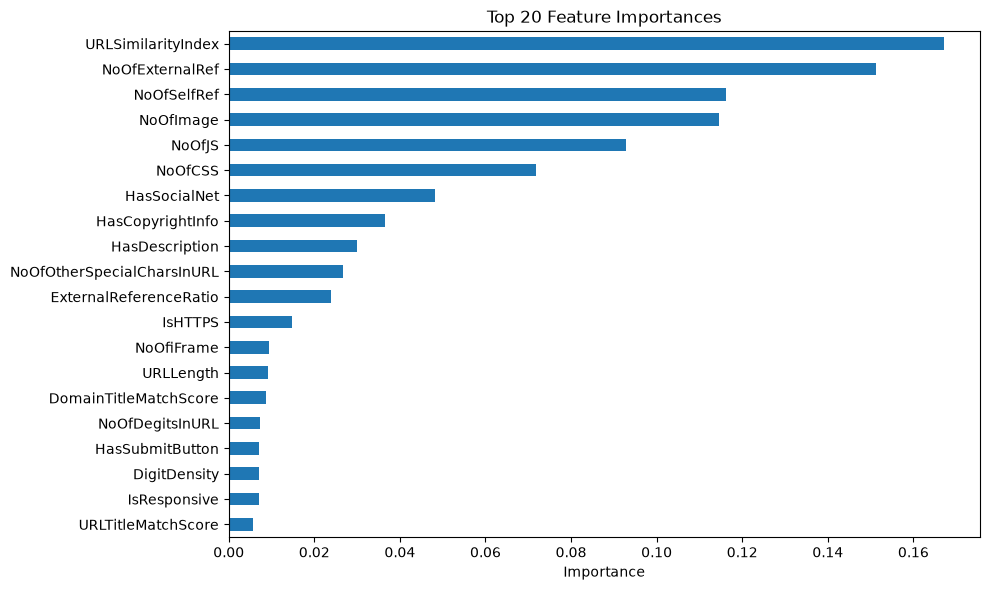

In [43]:
plt.figure(figsize=(10, 6))

feature_importance.head(20).sort_values().plot(
    kind="barh"
)

plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [1]:
duplicate_urls = df[df["URL"].duplicated(keep=False)].copy()

print("Total duplicate rows:", len(duplicate_urls))

print("\nDuplicate URLs by label:")
print(
    duplicate_urls.groupby("URL")["label"]
    .nunique()
    .value_counts()
)

NameError: name 'df' is not defined

In [2]:
import pandas as pd

DATA_PATH = "../data/raw/phiusiil/PhiUSIIL_Phishing_URL_Dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Dataset loaded successfully
Shape: (235795, 56)
Columns: ['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label']


In [3]:
duplicate_urls = df[df["URL"].duplicated(keep=False)].copy()

print("Total duplicate rows:", len(duplicate_urls))

print("\nDuplicate URLs by label:")
print(
    duplicate_urls.groupby("URL")["label"]
    .nunique()
    .value_counts()
)

Total duplicate rows: 850

Duplicate URLs by label:
label
1    425
Name: count, dtype: int64


In [4]:
mixed_label_duplicates = (
    duplicate_urls.groupby("URL")["label"]
    .nunique()
)

print(
    "URLs appearing with different labels:",
    (mixed_label_duplicates > 1).sum()
)

URLs appearing with different labels: 0


In [5]:
print("\nDuplicate rows by label:")
print(duplicate_urls["label"].value_counts())

print("\nPercentage of duplicate rows by label:")
print(
    duplicate_urls["label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


Duplicate rows by label:
label
0    850
Name: count, dtype: int64

Percentage of duplicate rows by label:
label
0    100.0
Name: proportion, dtype: float64


In [6]:
mixed_label_duplicates = (
    duplicate_urls.groupby("URL")["label"]
    .nunique()
)

print(
    "URLs appearing with different labels:",
    (mixed_label_duplicates > 1).sum()
)

URLs appearing with different labels: 0


In [7]:
df_clean = df.drop_duplicates(subset="URL", keep="first").copy()

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)
print("Rows removed:", len(df) - len(df_clean))

Original dataset shape: (235795, 56)
Cleaned dataset shape: (235370, 56)
Rows removed: 425


In [8]:
print("Remaining duplicate URLs:")
print(df_clean["URL"].duplicated().sum())

Remaining duplicate URLs:
0


In [9]:
print("\nLabel distribution after deduplication:")
print(df_clean["label"].value_counts())

print("\nLabel percentages:")
print(
    df_clean["label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


Label distribution after deduplication:
label
1    134850
0    100520
Name: count, dtype: int64

Label percentages:
label
1    57.29
0    42.71
Name: proportion, dtype: float64


In [10]:
CLEAN_PATH = "../data/processed/cleaned_url_dataset.csv"

df_clean.to_csv(CLEAN_PATH, index=False)

print("Cleaned dataset saved to:")
print(CLEAN_PATH)

Cleaned dataset saved to:
../data/processed/cleaned_url_dataset.csv
